In [112]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tensorflow.keras.optimizers import Adam

In [113]:
df= pd.read_csv("IMDB Dataset.csv")

In [114]:
df.head()



,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [115]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [116]:
df.duplicated().sum()

np.int64(418)

In [117]:
df=df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [118]:
df['sentiment'].value_counts()

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

In [125]:
analyse= SentimentIntensityAnalyzer()
df['vader']= df['review'].apply(lambda x: analyse.polarity_scores(x)['compound'])

In [126]:
df['vader'].head()

0   -0.9916
1    0.9670
2    0.9519
3   -0.9213
4    0.9744
Name: vader, dtype: float64

In [127]:
df['textblob'] = df['review'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['textblob'].head()

0    0.023433
1    0.109722
2    0.354008
3   -0.057813
4    0.217952
Name: textblob, dtype: float64

In [128]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 49582 entries, 0 to 49999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   review     49582 non-null  object 
 1   sentiment  49582 non-null  object 
 2   vader      49582 non-null  float64
 3   textblob   49582 non-null  float64
dtypes: float64(2), object(2)
memory usage: 1.9+ MB


In [123]:
df.shape



(49582, 4)

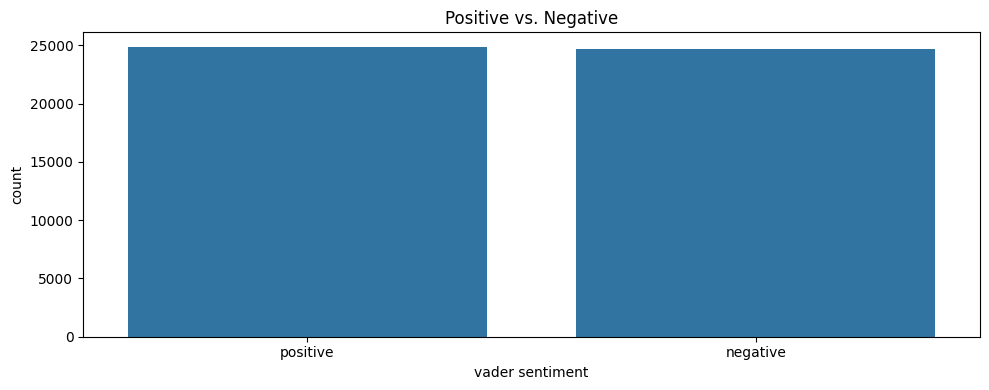

In [124]:
plt.figure(figsize=(10,4))
sns.countplot(x='sentiment', data= df)
plt.title('Positive vs. Negative')
plt.xlabel('vader sentiment')
plt.ylabel('count')
plt.tight_layout()
plt.show()


In [129]:
X= df[['vader', 'textblob']].values

In [130]:
X[:5]


array([[-0.9916    ,  0.02343318],
       [ 0.967     ,  0.10972222],
       [ 0.9519    ,  0.35400794],
       [-0.9213    , -0.0578125 ],
       [ 0.9744    ,  0.21795225]])

In [131]:
df['label']= df['sentiment'].map({'positive':1, 'negative':0})

In [132]:
df['label'].head()

0    1
1    1
2    1
3    0
4    1
Name: label, dtype: int64

In [133]:
Y= df['label'].values

In [134]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, Y, test_size=0.30, random_state=42, stratify=Y
)

In [135]:
X_val, X_test, Y_val, Y_test= train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

In [137]:
X_train. shape, y_train.shape, y_temp.shape


((34707, 2), (34707,), (14875,))

In [148]:
model= Sequential([
    Input(shape=(2, )),
    Dense(8, activation='relu'),
    Dense(4, activation='relu'),
    
    Dense(1, activation='sigmoid')
    
])

In [149]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("\nModel summary:")
model.summary()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, Y_val),
    epochs=20,
    batch_size=64,
    verbose=1
)


Model summary:


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_29 (Dense)                │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 920us/step - accuracy: 0.6764 - loss: 0.6387 - val_accuracy: 0.7300 - val_loss: 0.5461
Epoch 2/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 673us/step - accuracy: 0.7537 - loss: 0.5122 - val_accuracy: 0.7647 - val_loss: 0.4981
Epoch 3/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 652us/step - accuracy: 0.7683 - loss: 0.4871 - val_accuracy: 0.7670 - val_loss: 0.4875
Epoch 4/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 661us/step - accuracy: 0.7701 - loss: 0.4824 - val_accuracy: 0.7652 - val_loss: 0.4863
Epoch 5/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step - accuracy: 0.7710 - loss: 0.4821 - val_accuracy: 0.7664 - val_loss: 0.4856
Epoch 6/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 711us/step - accuracy: 0.7707 - loss: 0.4817 - val_accuracy: 0.7651 - val_loss: 0.4851
Epoch 7/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 669us/step - accuracy: 0.7705 - loss: 0.4814 - val_accuracy: 0.7659 - val_loss: 0.4852
Epoch 8/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 657us/step - accuracy: 0.7707 - loss: 0.4813 - 

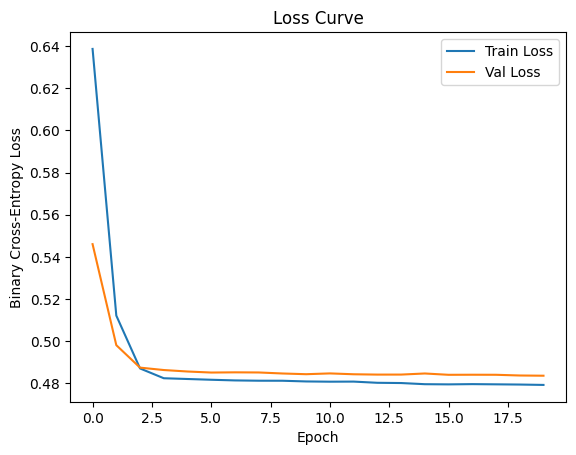

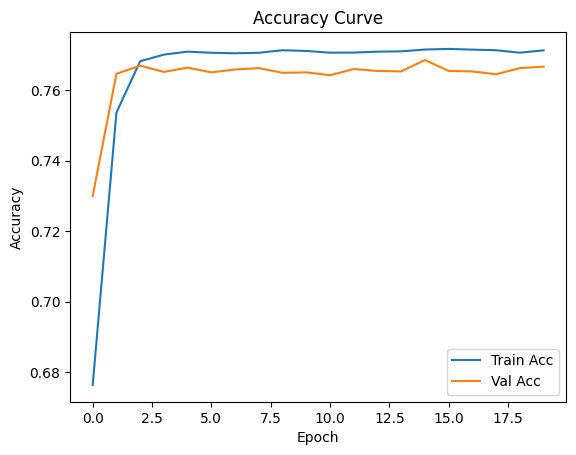

In [150]:
plt.figure()
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.show()

#  Accuracy curves
plt.figure()
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [151]:
#  to evaluate the loss and accuracy
test_loss, test_acc = model.evaluate(X_test, Y_test, verbose=0)
print("Test Results ")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

y_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Accuracy
acc = accuracy_score(Y_test, y_pred)
print("Accuracy:", acc)

cm = confusion_matrix(Y_test, y_pred)
print("confusion matrix ")
print(cm)

print("classification Report ")
print(classification_report(Y_test, y_pred, target_names=["negative", "positive"]))

Test Results 
Test Loss: 0.47683781385421753
Test Accuracy: 0.7700994610786438
Accuracy: 0.7700994891099758
confusion matrix 
[[2847  858]
 [ 852 2881]]
classification Report 
              precision    recall  f1-score   support

    negative       0.77      0.77      0.77      3705
    positive       0.77      0.77      0.77      3733

    accuracy                           0.77      7438
   macro avg       0.77      0.77      0.77      7438
weighted avg       0.77      0.77      0.77      7438

